In [ ]:
!pip install pandas matplotlib seaborn wordcloud google-cloud-language openpyxl

Saving train.xlsx to train (1).xlsx


<ipython-input-4-e94cedd8d19d>:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette='viridis')


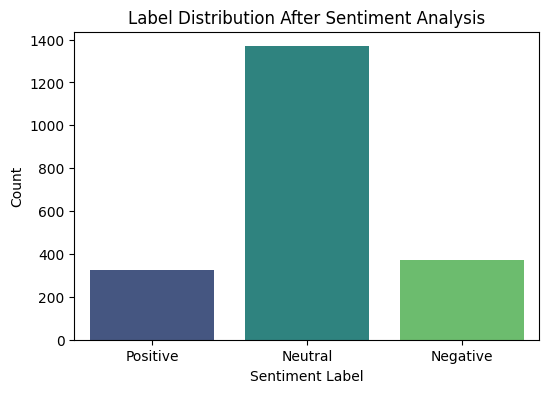

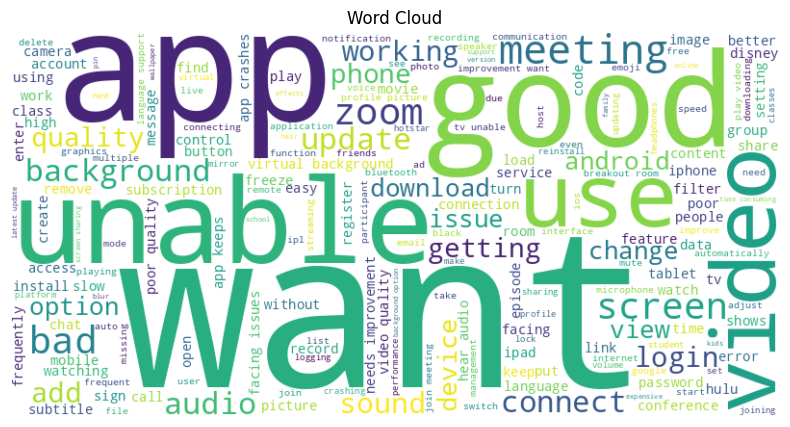

<ipython-input-4-e94cedd8d19d>:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_counts), y=list(top_words), palette='Blues_d')


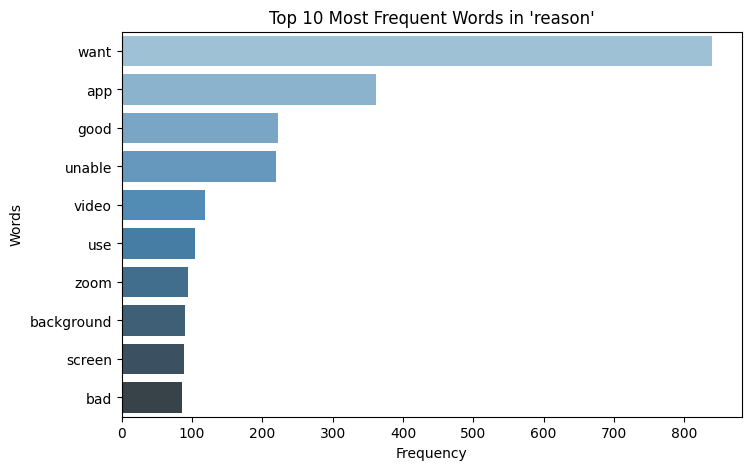

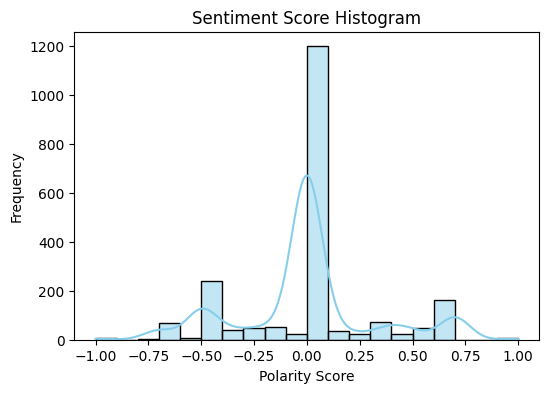

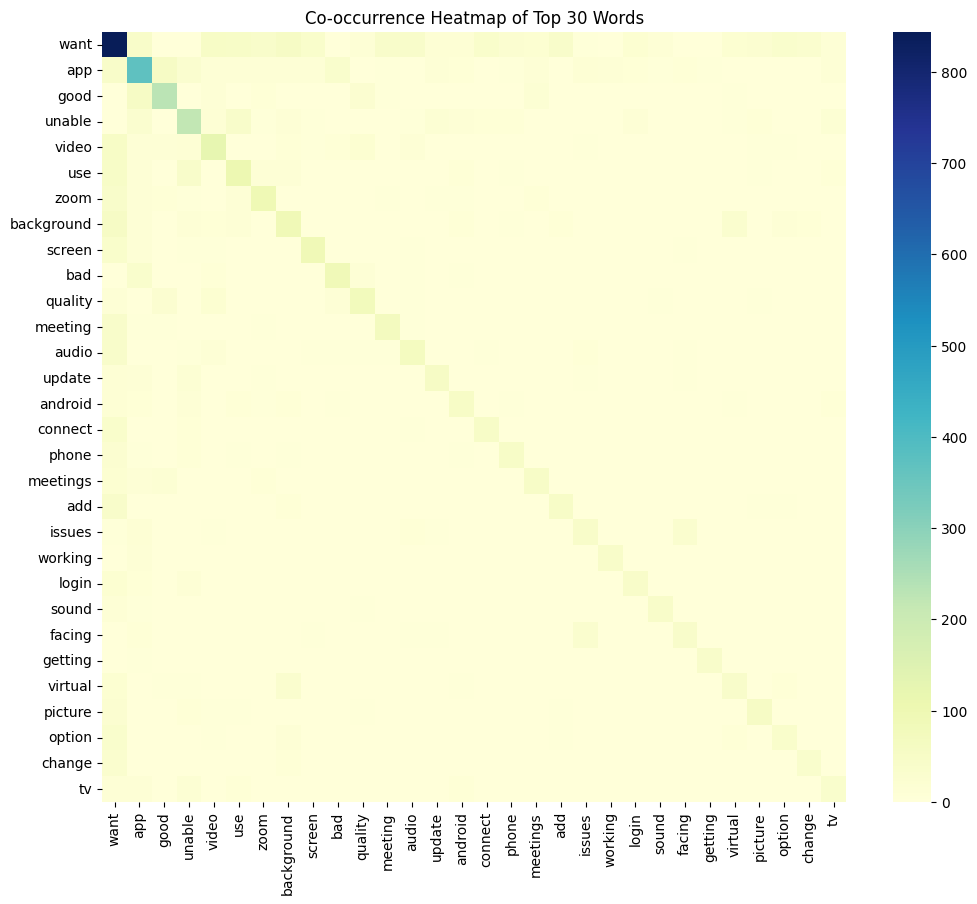

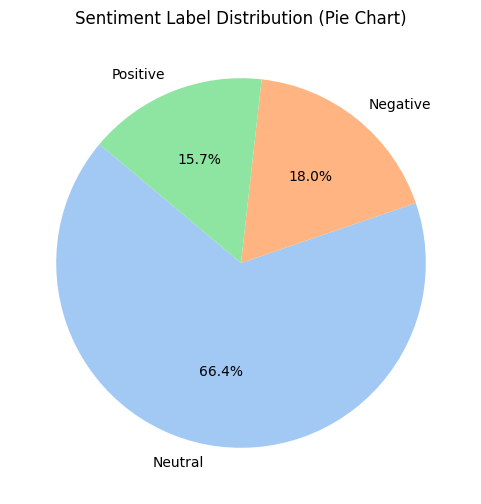

In [4]:


# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from google.colab import files

# Step 3: Upload the Excel file
uploaded = files.upload()  # Upload 'train.xlsx'

# Step 4: Load Excel data
df = pd.read_excel("train.xlsx")
assert 'reason' in df.columns, "'reason' column must exist in the dataset."

# Step 5: Sentiment Analysis using TextBlob
def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity

df['sentiment_score'] = df['reason'].apply(get_sentiment)

def get_label(score):
    if score > 0.25:
        return 'Positive'
    elif score < -0.25:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(get_label)

# ────────────────────────────────────────────────────────────────
# Visualization 1: Label Distribution After Sentiment Analysis
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment_label', data=df, palette='viridis')
plt.title('Label Distribution After Sentiment Analysis')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.savefig("1_label_distribution.png")
plt.show()

# ────────────────────────────────────────────────────────────────
# Visualization 2: Word Cloud of All Feedback
text = ' '.join(df['reason'].dropna().astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.savefig("2_wordcloud.png")
plt.show()

# ────────────────────────────────────────────────────────────────
# Visualization 3: Top 10 Frequent Words in "reason" After Stopword Removal
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['reason'].dropna().astype(str))
word_freq = zip(vectorizer.get_feature_names_out(), X.toarray().sum(axis=0))
sorted_words = sorted(word_freq, key=lambda x: x[1], reverse=True)
top_words, top_counts = zip(*sorted_words[:10])
plt.figure(figsize=(8, 5))
sns.barplot(x=list(top_counts), y=list(top_words), palette='Blues_d')
plt.title("Top 10 Most Frequent Words in 'reason'")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.savefig("3_top_words.png")
plt.show()

# ────────────────────────────────────────────────────────────────
# Visualization 4: Sentiment Score Histogram
plt.figure(figsize=(6, 4))
sns.histplot(df['sentiment_score'], bins=20, kde=True, color='skyblue')
plt.title('Sentiment Score Histogram')
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.savefig("4_sentiment_histogram.png")
plt.show()

# ────────────────────────────────────────────────────────────────
# Visualization 5: Co-occurrence Heatmap of Top 30 Words
top_30_words = [word for word, _ in sorted_words[:30]]
vectorizer_30 = CountVectorizer(vocabulary=top_30_words, stop_words='english')
X_30 = vectorizer_30.fit_transform(df['reason'].dropna().astype(str)).toarray()
co_occurrence_matrix = np.dot(X_30.T, X_30)
plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_matrix, xticklabels=top_30_words, yticklabels=top_30_words, cmap='YlGnBu')
plt.title('Co-occurrence Heatmap of Top 30 Words')
plt.savefig("5_cooccurrence_heatmap.png")
plt.show()

# ────────────────────────────────────────────────────────────────
# Visualization 6: Pie Chart of Sentiment Labels
plt.figure(figsize=(6, 6))
df['sentiment_label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel")
)
plt.title("Sentiment Label Distribution (Pie Chart)")
plt.ylabel("")
plt.savefig("6_sentiment_piechart.png")
plt.show()

# Optional: Download images
# from google.colab import files
# for i in range(1, 7):
#     files.download(f"{i}_*.png")
